In [1]:
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

In [2]:
seed = 42

### **Data Loading**

In [3]:
train = pd.read_csv("data/train.csv")

X_train = train.drop(columns=["Risk_Level"])
y_train = train["Risk_Level"].copy()

In [4]:
test = pd.read_csv("data/test.csv")

X_test = test.drop(columns=["Risk_Level"])
y_test = test["Risk_Level"].copy()

### **Model Loading**

In [5]:
# Logistic Regression
with open("models/LogisticRegression.pkl", "rb") as f:
    logit = pickle.load(f)

# Linear Discriminant Analysis
with open("models/LDA.pkl", "rb") as f:
    lda = pickle.load(f)

# Support Vector Machine (RBF)
with open("models/SVM-RBF.pkl", "rb") as f:
    svm_rbf = pickle.load(f)

# Support Vector Machine (Linear)
with open("models/SVM-Linear.pkl", "rb") as f:
    svm_linear = pickle.load(f)

# Random Forest
with open("models/RandomForest.pkl", "rb") as f:
    rf = pickle.load(f)

# Multi-Layer Perceptron
with open("models/MLP.pkl", "rb") as f:
    mlp = pickle.load(f)

### **Importancias Nativas**

Las importancias nativas son medidas internas generadas directamente por el modelo para cuantificar la contribución de cada característica a las predicciones. En modelos lineales coef_ indican la relación y el peso de cada variable en la salida del modelo. En modelos basados en árboles la propiedad feature_importances_ refleja la reducción promedio de impureza o ganancia de información que aporta cada característica al dividir los nodos del árbol. Estas medidas son específicas del tipo de modelo y permiten identificar de manera rápida qué variables influyen más en el ajuste interno del modelo.

In [6]:
feature_names = X_train.columns.tolist()

coef_logit = np.mean(np.abs(logit.best_estimator_.coef_), axis=0)
imp_logit_native = pd.Series(coef_logit, index=feature_names)

coef_lda = np.mean(np.abs(lda.best_estimator_.coef_), axis=0)
imp_lda_native = pd.Series(coef_lda, index=feature_names)

coef_svm_lin = np.mean(np.abs(svm_linear.best_estimator_.coef_), axis=0)
imp_svm_lin_native = pd.Series(coef_svm_lin, index=feature_names)

imp_rf_native = pd.Series(rf.best_estimator_.feature_importances_, index=feature_names)

### **Permutation Importance**

Permutation Importance es una técnica de interpretación de modelos que mide la importancia de cada característica evaluando la disminución en el rendimiento del modelo cuando los valores de esa característica se permutan aleatoriamente. Si al permutar una variable el desempeño del modelo se degrada significativamente, se considera que dicha variable tiene alta importancia; si el cambio es mínimo, su contribución al modelo es baja. Este método es independiente del tipo de modelo y permite estimar la relevancia real de cada atributo en la predicción.

In [7]:
def get_perm_importance_series(model, X, y, feature_names, n_repeats=40, random_state=seed, scoring='recall_macro'):
    res = permutation_importance(model, X, y, n_repeats=n_repeats, random_state=random_state, scoring=scoring, n_jobs=-1)
    imp_mean = res.importances_mean
    s = pd.Series(imp_mean, index=feature_names)
    return s

In [8]:
feature_names = X_train.columns.tolist()

perm_logit = get_perm_importance_series(logit, X_test, y_test, feature_names)
perm_lda = get_perm_importance_series(lda, X_test, y_test, feature_names)
perm_svm_rbf = get_perm_importance_series(svm_rbf, X_test, y_test, feature_names)
perm_svm_linear = get_perm_importance_series(svm_linear, X_test, y_test, feature_names)
perm_rf = get_perm_importance_series(rf, X_test, y_test, feature_names)
perm_mlp = get_perm_importance_series(mlp, X_test, y_test, feature_names)

### **Top Features**

In [9]:
def normalize_series(s):
    mx = s.max()
    if mx == 0 or np.isnan(mx):
        return s * 0.0
    return s / mx

feature_names = X_train.columns.tolist()

df_imp = pd.DataFrame({"feature": feature_names}).set_index("feature")

df_imp["native_logit"] = normalize_series(imp_logit_native)
df_imp["native_lda"] = normalize_series(imp_lda_native)
df_imp["native_svm_linear"] = normalize_series(imp_svm_lin_native)
df_imp["native_rf"] = normalize_series(imp_rf_native)

df_imp["perm_logit"] = normalize_series(perm_logit)
df_imp["perm_lda"] = normalize_series(perm_lda)
df_imp["perm_svm_rbf"] = normalize_series(perm_svm_rbf)
df_imp["perm_svm_linear"] = normalize_series(perm_svm_linear)
df_imp["perm_rf"] = normalize_series(perm_rf)
df_imp["perm_mlp"] = normalize_series(perm_mlp)

df_imp["logit"] = df_imp["native_logit"].fillna(df_imp["perm_logit"])
df_imp["lda"] = df_imp["native_lda"].fillna(df_imp["perm_lda"])
df_imp["svm_linear"] = df_imp["native_svm_linear"].fillna(df_imp["perm_svm_linear"])
df_imp["rf"] = df_imp["native_rf"].fillna(df_imp["perm_rf"])
df_imp["svm_rbf"] = df_imp["perm_svm_rbf"]
df_imp["mlp"] = df_imp["perm_mlp"]

In [10]:
cols_to_merge = ["logit","lda","svm_linear","svm_rbf","rf","mlp"]

df_imp["mean_importance"] = df_imp[cols_to_merge].mean(axis=1)
df_imp["median_importance"] = df_imp[cols_to_merge].median(axis=1)
df_imp["rank"] = df_imp["mean_importance"].rank(ascending=False, method="min").astype(int)

df_ranked = df_imp.sort_values("mean_importance", ascending=False)
df_ranked.head(30)

,native_logit,native_lda,native_svm_linear,native_rf,perm_logit,perm_lda,perm_svm_rbf,perm_svm_linear,perm_rf,perm_mlp,logit,lda,svm_linear,rf,svm_rbf,mlp,mean_importance,median_importance,rank
feature,,,,,,,,,,,,,,,,,,,
Complexity_Score,0.593201,0.066691,0.518135,1.000000,1.000000,1.000000,1.000000,1.000000,0.621569,1.000000,0.593201,0.066691,0.518135,1.000000,1.000000,1.000000,0.696338,0.796600,1
Technology_Familiarity_Expert,0.805100,0.933156,0.749685,0.249545,0.528141,0.472108,0.502470,0.490734,0.263238,0.627930,0.805100,0.933156,0.749685,0.249545,0.502470,0.627930,0.644648,0.688807,2
Technology_Familiarity_New,0.785557,0.934742,0.760594,0.307503,0.313313,0.503952,0.438062,0.299916,0.401339,0.543022,0.785557,0.934742,0.760594,0.307503,0.438062,0.543022,0.628247,0.651808,3
Key_Stakeholder_Availability_Excellent,1.000000,0.544206,1.000000,0.238259,0.360799,0.349462,0.432402,0.342900,1.000000,0.417432,1.000000,0.544206,1.000000,0.238259,0.432402,0.417432,0.605383,0.488304,4
Team_Experience_Level_Expert,0.934205,0.625939,0.910826,0.361346,0.205645,0.311511,0.227329,0.281055,0.459229,0.483866,0.934205,0.625939,0.910826,0.361346,0.227329,0.483866,0.590585,0.554903,5
Stakeholder_Engagement_Level_Excellent,0.821124,0.558432,0.838780,0.163753,0.476755,0.452834,0.492171,0.461804,0.392055,0.530495,0.821124,0.558432,0.838780,0.163753,0.492171,0.530495,0.567459,0.544463,6
Risk_Management_Maturity_Advanced,0.882753,0.640687,0.840357,0.244583,0.168770,0.293623,0.280419,0.224822,0.609612,0.495303,0.882753,0.640687,0.840357,0.244583,0.280419,0.495303,0.564017,0.567995,7
Change_Control_Maturity_None,0.831874,0.702597,0.882466,0.216076,0.239977,0.113996,0.271980,0.341357,0.432662,0.414817,0.831874,0.702597,0.882466,0.216076,0.271980,0.414817,0.553302,0.558707,8
Change_Control_Maturity_Advanced,0.896713,0.650928,0.840888,0.234125,0.224879,0.312710,0.236828,0.164104,0.453057,0.267268,0.896713,0.650928,0.840888,0.234125,0.236828,0.267268,0.521125,0.459098,9


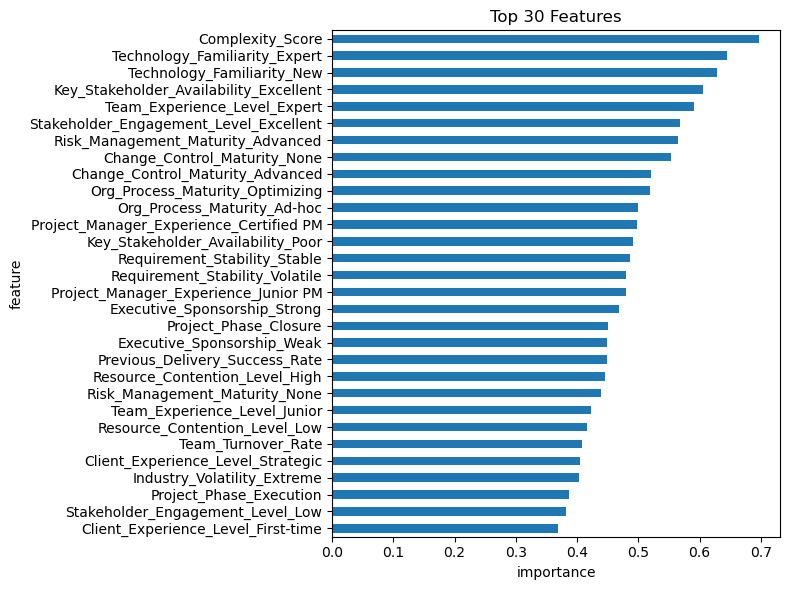

In [11]:
def plot_top_features(series, topn, title=None, figsize=(8,6)):
    s = series.sort_values(ascending=True).tail(topn)
    plt.figure(figsize=figsize)
    s.plot(kind="barh")
    plt.xlabel("importance")
    plt.title(title if title else series.name)
    plt.tight_layout()
    plt.show()

plot_top_features(df_ranked["mean_importance"], topn=30, title="Top 30 Features")